In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("C:/Users/RAHUL YADAV/OneDrive/credit-risk-analysis/data/featured/loan_default_cleaned.csv")

In [13]:
total_applications = len(df)

default_rate = df["default"].mean()*100

total_loan_amount = df["loanamount"].sum()

average_loan_amount = df["loanamount"].mean()

average_income = df["income"].mean()

average_credit_score = df["creditscore"].mean()

average_interest_rate = df["interestrate"].mean()

In [14]:
print(f"Total Applications : {total_applications:,}")

print(f"Default Rate : {default_rate:.2f}%")

print(f"Total Loan Amount : ${total_loan_amount:,.0f}")

print(f"Average Loan Amount : ${average_loan_amount:,.2f}")

print(f"Average Income : ${average_income:,.2f}")

print(f"Average Credit Score : {average_credit_score:.0f}")

print(f"Average Interest Rate : {average_interest_rate:.2f}%")

Total Applications : 255,347
Default Rate : 11.61%
Total Loan Amount : $32,576,880,572
Average Loan Amount : $127,578.87
Average Income : $82,499.30
Average Credit Score : 574
Average Interest Rate : 13.49%


Business Question 1

What is the overall loan default distribution?

In [73]:
default_percentage = (
    df["default"]
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
)

default_percentage.columns = ["Loan Status", "Percentage"]

default_percentage["Loan Status"] = default_percentage["Loan Status"].replace({
    0: "No Default",
    1: "Default"
})

default_percentage

,Loan Status,Percentage
0,No Default,88.387175
1,Default,11.612825


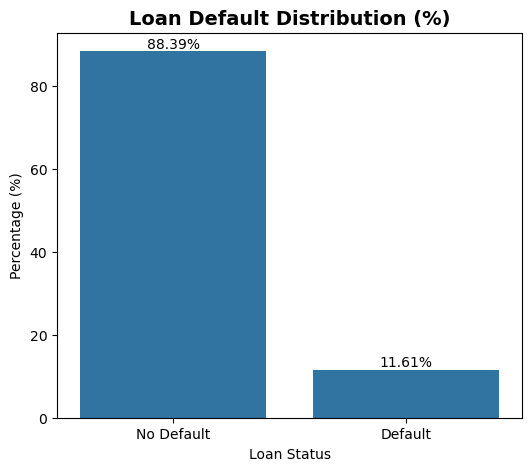

In [74]:
plt.figure(figsize=(6,5))

ax = sns.barplot(
    data=default_percentage,
    x="Loan Status",
    y="Percentage"
)

plt.title("Loan Default Distribution (%)", fontsize=14, fontweight="bold")
plt.xlabel("Loan Status")
plt.ylabel("Percentage (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.show()

Business Insight

Approximately 11.6% of customers defaulted on their loans, while 88.4% successfully repaid them. Although the majority of borrowers repay their loans, the default segment represents a significant source of credit risk for the bank. Understanding the characteristics of these defaulting customers will help improve lending decisions and reduce future financial losses.

Business Question 2

Which age group has the highest default rate?

In [20]:
age_default = (df.groupby("agegroup")["default"].mean().mul(100).reset_index())

age_default

,agegroup,default
0,18-30,19.385941
1,31-45,12.695262
2,45-60,7.742752
3,60+,5.054070


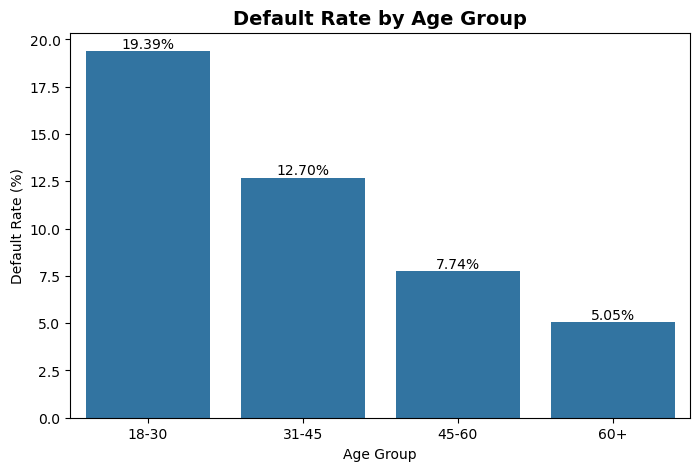

In [59]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=age_default,
    x="agegroup",
    y="default"
)

plt.title("Default Rate by Age Group", fontsize=14, fontweight="bold")
plt.xlabel("Age Group")
plt.ylabel("Default Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.show()

Business Insight

Customers in the 18-30 Age Group recorded the highest default rate among all age groups. This suggests that borrowers within this age segment may have a comparatively higher repayment risk. However, age should be evaluated alongside other financial indicators such as income, credit score, employment stability, and debt-to-income ratio before making lending decisions.

Business Question 3

Which income group has the highest default rate?

In [67]:
income_default = (df.groupby("incomegroup")["default"].mean().mul(100).reset_index())

income_default

,incomegroup,default
0,High,9.103791
1,Low,17.162136
2,Medium,10.244711


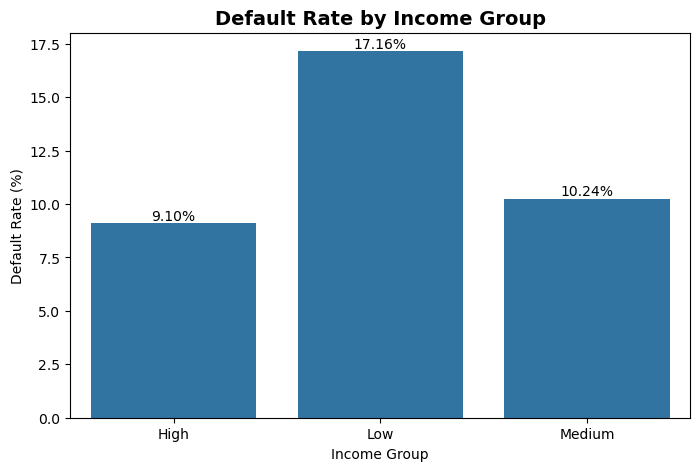

In [58]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=income_default,
    x="incomegroup",
    y="default"
)

plt.title("Default Rate by Income Group", fontsize=14, fontweight="bold")
plt.xlabel("Income Group")
plt.ylabel("Default Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.show()

Business Insight

The Low income group experienced the highest default rate. This finding indicates that income alone is not sufficient to predict loan repayment behavior. Additional financial indicators such as credit score, debt-to-income ratio, and employment history should also be considered when evaluating loan applications.

Business Question 4

Does credit score affect loan default?

In [10]:
credit_default = (df.groupby("creditcategory")["default"].mean().mul(100).reset_index())

credit_default

,creditcategory,default
0,Excellent,10.167221
1,Fair,11.423932
2,Good,10.627989
3,Poor,12.475900


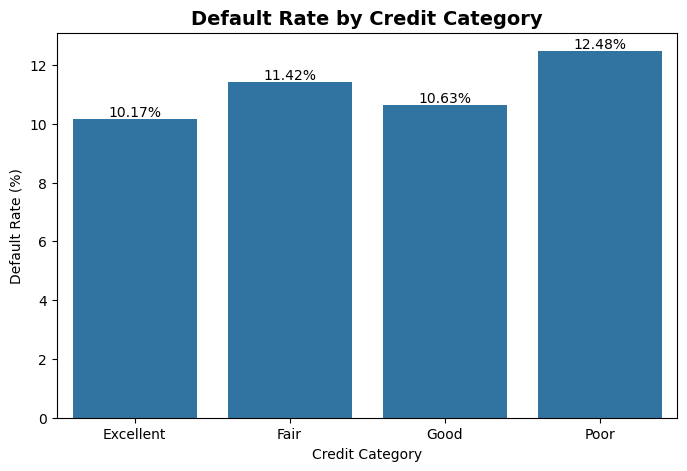

In [53]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=credit_default,
    x="creditcategory",
    y="default"
)

plt.title("Default Rate by Credit Category", fontsize=14, fontweight="bold")
plt.xlabel("Credit Category")
plt.ylabel("Default Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.show()

Customers in the Poor credit category exhibited the highest default rate. This suggests that credit score is an important indicator of repayment behavior and should remain one of the primary factors considered during the loan approval process.

Business Question 5

Which education level has the highest default rate?

In [27]:
education_default = (df.groupby("education")["default"].mean().mul(100).sort_values(ascending=False).reset_index())

education_default

,education,default
0,High School,12.878895
1,Bachelor's,12.101109
2,Master's,10.871721
3,PhD,10.585958


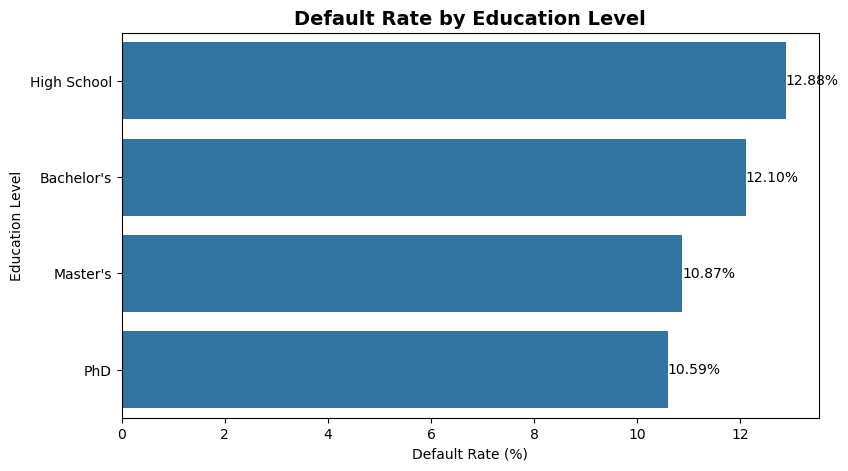

In [29]:
plt.figure(figsize=(9,5))

ax = sns.barplot(
    data=education_default,
    y="education",
    x="default"
)

plt.title("Default Rate by Education Level", fontsize=14, fontweight="bold")
plt.xlabel("Default Rate (%)")
plt.ylabel("Education Level")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.show()

Business Insight

Applicants with High School recorded the highest default rate among all education groups. While education may provide additional context about a borrower's background, it should not be used independently for lending decisions. Combining education with income, employment status, and credit score provides a more comprehensive assessment of repayment risk.

Business Question 6

Which employment type has the highest default rate?

In [30]:
employment_default = (df.groupby("employmenttype")["default"].mean().mul(100).sort_values(ascending=False).reset_index(name="default"))

employment_default

,employmenttype,default
0,Unemployed,13.552895
1,Part-time,11.965213
2,Self-employed,11.462029
3,Full-time,9.463366


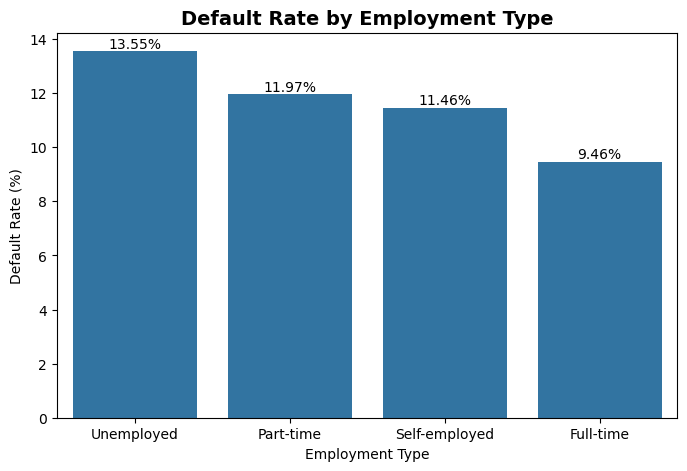

In [31]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=employment_default,
    x="employmenttype",
    y="default"
)

plt.title("Default Rate by Employment Type", fontsize=14, fontweight="bold")
plt.xlabel("Employment Type")
plt.ylabel("Default Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.show()

Business Insight

Customers with Unemployed employment showed the highest default rate. This suggests that employment status may influence repayment capacity and financial stability. Applicants within this employment category may require additional financial verification before loan approval.

Business Question 7

Which loan purpose has the highest default rate?

In [33]:
purpose_summary = (
    df.groupby("loanpurpose")
      .agg(
          Total_Applications=("loanpurpose", "count"),
          Default_Rate=("default", lambda x: x.mean() * 100)
      )
      .sort_values("Default_Rate", ascending=False)
      .reset_index()
)

purpose_summary

,loanpurpose,Total_Applications,Default_Rate
0,Business,51298,12.326017
1,Auto,50844,11.881441
2,Education,51005,11.838055
3,Other,50914,11.788506
4,Home,51286,10.234762


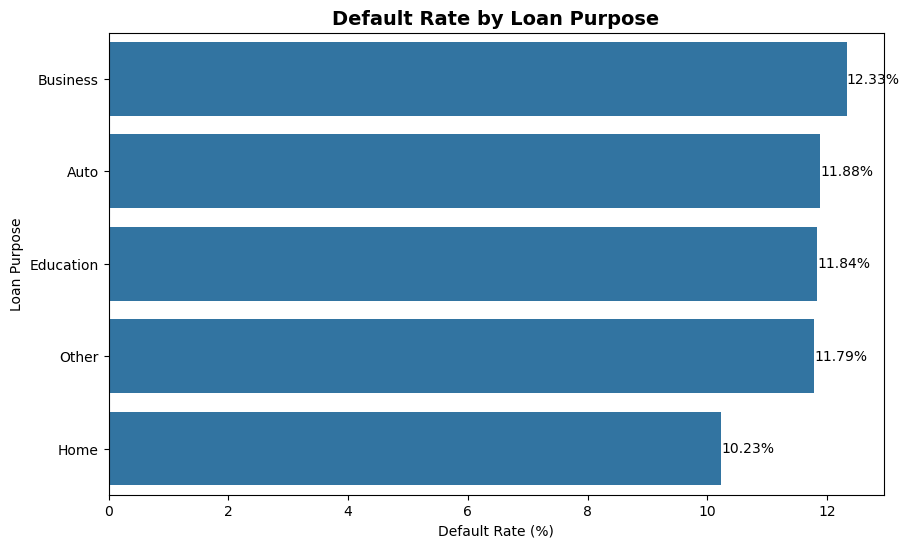

In [37]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=purpose_summary,
    y="loanpurpose",
    x="Default_Rate"
)

plt.title("Default Rate by Loan Purpose", fontsize=14, fontweight="bold")
plt.xlabel("Default Rate (%)")
plt.ylabel("Loan Purpose")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.show()

Loans issued for Business recorded the highest default rate among all loan purposes. This indicates that this category may carry greater repayment risk compared to other loan types. The bank should evaluate lending policies for this loan purpose while also considering the overall application volume.

Business Question 8

Does having a mortgage influence loan default?

In [38]:
mortgage_summary = (
    df.groupby("hasmortgage")
      .agg(
          Total_Applications=("hasmortgage", "count"),
          Default_Rate=("default", lambda x: x.mean()*100)
      )
      .reset_index()
)

mortgage_summary

,hasmortgage,Total_Applications,Default_Rate
0,No,127670,12.345108
1,Yes,127677,10.880581


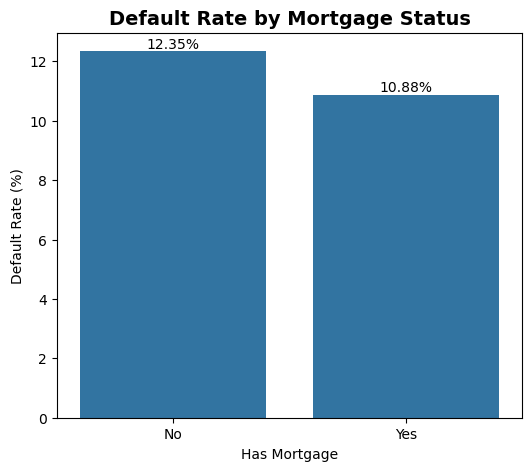

In [39]:
plt.figure(figsize=(6,5))

ax = sns.barplot(
    data=mortgage_summary,
    x="hasmortgage",
    y="Default_Rate"
)

plt.title("Default Rate by Mortgage Status", fontsize=14, fontweight="bold")
plt.xlabel("Has Mortgage")
plt.ylabel("Default Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.show()

Business Insight

The analysis indicates that customers Without a mortgage have a higher default rate. While mortgage ownership may reflect aspects of a customer's financial profile, it should not be considered a standalone indicator of repayment behavior. Mortgage status should be evaluated together with income, debt obligations, and credit history.

Business Question 9

Does having a co-signer reduce loan default risk?

In [40]:
cosigner_summary = (
    df.groupby("hascosigner")
      .agg(
          Total_Applications=("hascosigner", "count"),
          Default_Rate=("default", lambda x: x.mean() * 100)
      )
      .reset_index()
)

cosigner_summary

,hascosigner,Total_Applications,Default_Rate
0,No,127646,12.866051
1,Yes,127701,10.360138


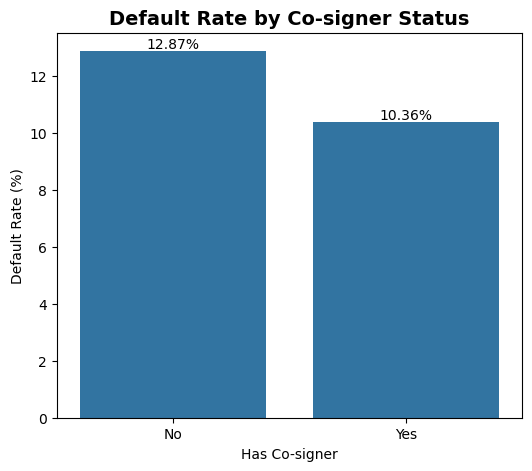

In [41]:
plt.figure(figsize=(6,5))

ax = sns.barplot(
    data=cosigner_summary,
    x="hascosigner",
    y="Default_Rate"
)

plt.title("Default Rate by Co-signer Status", fontsize=14, fontweight="bold")
plt.xlabel("Has Co-signer")
plt.ylabel("Default Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.show()

Business Insight

Customers With a co-signer exhibited a lower default rate. This suggests that the presence of a co-signer may improve repayment reliability by providing additional financial assurance. However, co-signer status should complement rather than replace other credit risk assessment criteria.

Business Question 10

What relationships exist among the numerical variables?

In [42]:
corr = df.select_dtypes(include=["int64", "float64"]).corr()

corr

,age,income,loanamount,creditscore,monthsemployed,numcreditlines,interestrate,loanterm,dtiratio,default
age,1.000000,-0.001244,-0.002213,-0.000548,-0.000341,-0.000890,-0.001127,0.000263,-0.004689,-0.167783
income,-0.001244,1.000000,-0.000865,-0.001430,0.002675,-0.002016,-0.002303,-0.000998,0.000205,-0.099119
loanamount,-0.002213,-0.000865,1.000000,0.001261,0.002817,0.000794,-0.002291,0.002538,0.001122,0.086659
creditscore,-0.000548,-0.001430,0.001261,1.000000,0.000613,0.000016,0.000436,0.001130,-0.001039,-0.034166
monthsemployed,-0.000341,0.002675,0.002817,0.000613,1.000000,0.001267,0.000096,-0.001166,0.001765,-0.097374
numcreditlines,-0.000890,-0.002016,0.000794,0.000016,0.001267,1.000000,-0.000297,-0.000226,-0.000586,0.028330
interestrate,-0.001127,-0.002303,-0.002291,0.000436,0.000096,-0.000297,1.000000,0.000892,0.000575,0.131273
loanterm,0.000263,-0.000998,0.002538,0.001130,-0.001166,-0.000226,0.000892,1.000000,0.002273,0.000545
dtiratio,-0.004689,0.000205,0.001122,-0.001039,0.001765,-0.000586,0.000575,0.002273,1.000000,0.019236
default,-0.167783,-0.099119,0.086659,-0.034166,-0.097374,0.028330,0.131273,0.000545,0.019236,1.000000


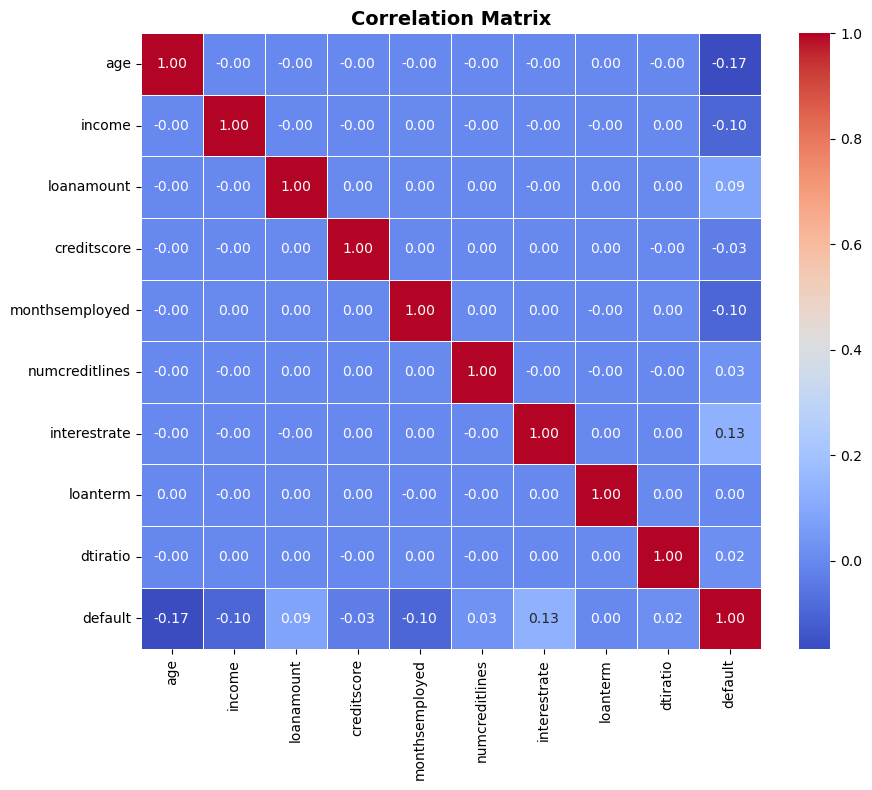

In [43]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix", fontsize=14, fontweight="bold")

plt.show()

Business Insight

The correlation analysis highlights the strength and direction of relationships between numerical variables. Variables showing relatively stronger positive or negative correlations with the loan default variable may serve as useful indicators for identifying higher-risk borrowers. However, correlation represents an association between variables and should not be interpreted as evidence of a cause-and-effect relationship.

EXECUTIVE SUMMARY

This exploratory data analysis examined historical loan application data to identify patterns associated with loan default. Customer demographics, financial characteristics, and loan attributes were analyzed to understand their relationship with repayment behavior. The analysis highlighted several customer segments with comparatively higher default rates and identified factors that may support more informed lending decisions. These findings provide a foundation for statistical analysis, SQL-based reporting, and dashboard development.

KEY FINDINGS


1. The overall loan default rate is 11.61%.
2. Customers in the 18-30 age group recorded the highest default rate.
3. The Low income group experienced the highest default rate.
4. Borrowers in the Poor credit category showed the highest default rate.
5. Customers with High School had the highest default rate among education groups.
6. Applicants with Unemployed employment status recorded the highest default rate.
7. Loans issued for Business had the highest default rate.
8. Customers without a mortgage exhibited a higher default rate.
9. Customers with a co-signer showed a lower default rate.
10. Correlation analysis indicated that Age had the strongest negative relationship with loan default among the numerical variables

BUSINESS RECCOMENDATIONS

1. Based on the exploratory analysis, the following recommendations are proposed:
2. Strengthen risk assessment for customer segments with higher observed default rates.
3. Continue using credit score as a key factor in loan approval decisions, alongside other financial indicators.
4. Review lending policies for loan purposes associated with higher default rates.
5. Assess applicants using a combination of income, employment status, debt-to-income ratio, and credit history rather than relying on a single variable.
6. Consider additional verification or supporting documentation for applicants belonging to higher-risk customer segments.
7. Use these analytical findings to support future credit risk models and improve lending strategies.
8. Develop an interactive dashboard to monitor default trends and portfolio performance on an ongoing basis.

FINAL NOTEBOOK CONCLUSION

The exploratory data analysis identified meaningful patterns in customer demographics, financial characteristics, and loan attributes that are associated with loan default. While these findings reveal important trends, they do not by themselves establish statistical significance or causal relationships. The next stage of the project will apply statistical testing to validate these observations before they are incorporated into business decision-making.